<a href="https://colab.research.google.com/github/tepherve-cmyk/DAAI_Project_HT/blob/main/Project4_Herve_Tepongning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## FINAL PROJECT
#Project Part 4

Name: Herve Tepongning Megnifo

Student Number: HT137724

Program: Business Intelligence Analyst

Course: Data Analytics and Artificial Intelligence Project

## Introduction



Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Data Preparation and Exploration

Load Dataset

In [5]:
# Load the MNIST dataset using Scikit-learn
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Separate images and labels
X = mnist.data
y = mnist.target

print("Data shape:", X.shape)
print("Labels shape:", y.shape)
print("Data type:", X.dtype)

Data shape: (70000, 784)
Labels shape: (70000,)
Data type: int64


In [4]:
# Size

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
'''
The pixel values range from 0 to 255.
'''

 Understand the 784 features

The MNIST dataset was loaded using the Scikit-learn library with fetch_openml().
It contains 70,000 digit images, with each image represented by 784 pixels corresponding to a 28 × 28 image.

 Display sample images

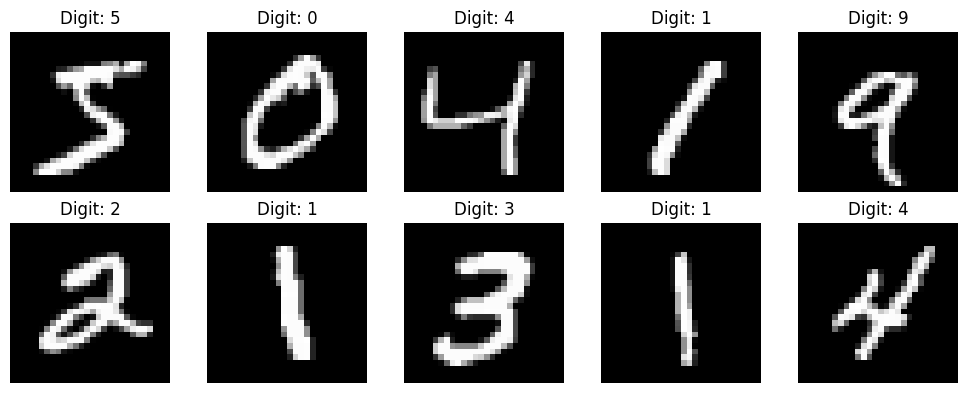

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(f"Digit: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
'''
The dataset contains handwritten digit images.
These 10 examples show that the same digit can look
different depending on the person's handwriting style

'''

"\nThe dataset contains handwritten digit images. \nThese 10 examples show that the same digit can look \ndifferent depending on the person's handwriting style\n\n"

Normalize the images

In [ ]:
# Normalize pixel values
X = X.astype('float32') / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

In [ ]:
'''
The images were normalized by dividing the pixel values by 255.
Therefore, the pixel values range from 0 to 1.

'''

Questions and answers:

1. How many images are in the dataset?

The dataset contains 70,000 handwritten digit images.

2. Why does each image have 784 features?

Each image has a size of 28 × 28 pixels. Therefore, each image contains 28 × 28 = 784 pixels, and each pixel is treated as one feature.

3. What do the pixel values represent?

The pixel values represent the brightness of each pixel in the handwritten image.

4. Why do images of the same digit look different?

Images of the same digit can look different because they are handwritten by different people. Each person has their own handwriting style.

5. Why do we normalize the pixel values?

We normalize the pixel values because different pixel values can have different scales and influence the model. By putting all pixel values in a range from 0 to 1, the model can process the data more consistently.

Part 2: Discover Groups Using K-Means

 Use a manageable sample

In [11]:
import numpy as np

# Create a random generator
rng = np.random.RandomState(42)

# Select 10,000 random images
sample_indices = rng.choice(
    len(X),
    size=10000,
    replace=False
)

# Create the sample
X_sample = X[sample_indices]
y_sample = y[sample_indices]

print("Sample data shape:", X_sample.shape)
print("Sample labels shape:", y_sample.shape)

Sample data shape: (10000, 784)
Sample labels shape: (10000,)


In [13]:
'''
A sample of 10,000 images is used to make the analysis more manageable,
with each image included only once
'''

'\nA sample of 10,000 images is used to make the analysis more manageable, \nwith each image included only once\n'

2.2 Find a reasonable number of clusters

In [14]:
from sklearn.cluster import KMeans

inertia = []

for k in [5, 10, 15]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)

print("Inertia values:", inertia)

Inertia values: [28125117004.77301, 25382057659.10338, 23768278243.732895]


In [ ]:
'''

The K-Means algorithm was tested with 5, 10, and 15 clusters.
The inertia was calculated for each value of K to determine a reasonable number of clusters.

'''

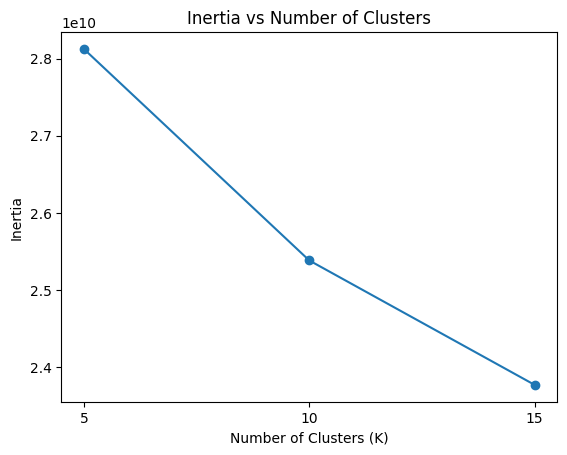

In [15]:
# Create a Line Chart showing Inertia and Number of Clusters

import matplotlib.pyplot as plt

K_values = [5, 10, 15]

plt.plot(K_values, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Inertia vs Number of Clusters')
plt.xticks(K_values)
plt.show()

The graph shows that inertia decreases as K increases. Around 10 clusters, the slope of the curve changes and the decrease in inertia becomes smaller. Therefore, K = 10 is chosen as the number of clusters.

Train the final K-Means model

In [16]:
# Train the Final K-Means Model

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_sample)

print("Cluster labels:", clusters[:20])

Cluster labels: [3 2 5 2 2 0 9 4 7 4 8 4 4 3 1 3 2 7 2 5]


In [ ]:
'''
The final K-Means model was trained using 10 clusters,
based on the elbow analysis. Each image was then assigned
to one of the 10 clusters.
'''

Check the cluster sizes

In [17]:
# Count the Number of Images in Each Cluster

import pandas as pd

cluster_counts = pd.Series(clusters).value_counts().sort_index()

print(cluster_counts)

0     519
1     757
2    1487
3    1039
4    1475
5    1331
6     513
7     906
8    1017
9     956
Name: count, dtype: int64


In [ ]:
'''
The images were assigned to the 10 clusters.
Cluster 2 has the largest number of images, with 1,487,
followed by Cluster 4 with 1,475 images.
Cluster 6 has the smallest number of images, with 513.

'''

Questions and Answers

1. Which value of K did you choose?
I selected K=10

2. Why did you choose it?
Because the elbow in the inertia curve appears around 10 clusters. After this point, increasing K provides a smaller reduction in inertia.

3. How many images are in each cluster?

Here is the distribution of images across the 10 clusters.

Cluster 0: 519 images
Cluster 1: 757 images
Cluster 2: 1,487 images
Cluster 3: 1,039 images
Cluster 4: 1,475 images
Cluster 5: 1,331 images
Cluster 6: 513 images
Cluster 7: 906 images
Cluster 8: 1,017 images
Cluster 9: 956 images

4. Are the clusters approximately the same size?

The clusters are not approximately the same size. The cluster sizes range from 513 to 1,487 images.
Therefore, there is a noticeable difference in cluster sizes.


# Part 3 - Understand the Clusters

Display all cluster centroids

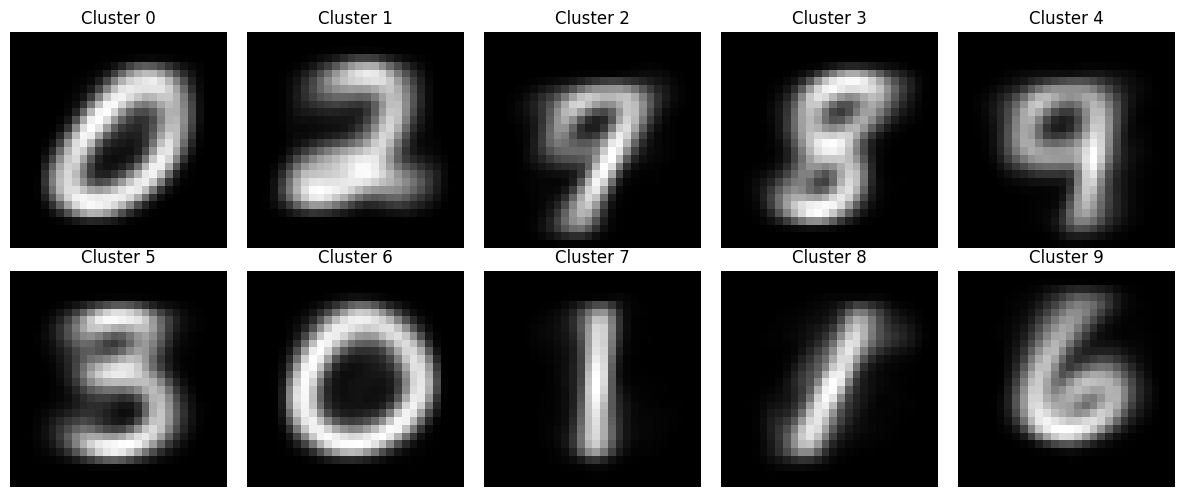

In [18]:
# Display the Centroid of Each K-Means Cluster

import matplotlib.pyplot as plt

centroids = kmeans.cluster_centers_

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(centroids[i].reshape(28, 28), cmap="gray")
    plt.title(f"Cluster {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Some centroids clearly resemble recognizable digits. For example, Cluster 1 appears similar to digit 2, Cluster 9 resembles digit 6, and Cluster 3 resembles digit 8.

Other centroids are more difficult to interpret. For example, Clusters 0 and 6 both appear similar to digit 0, while Clusters 2 and 4 have similar shapes and resemble digit 9. Clusters 7 and 8 also appear similar and resemble digit 1.

Display individual images from each cluster

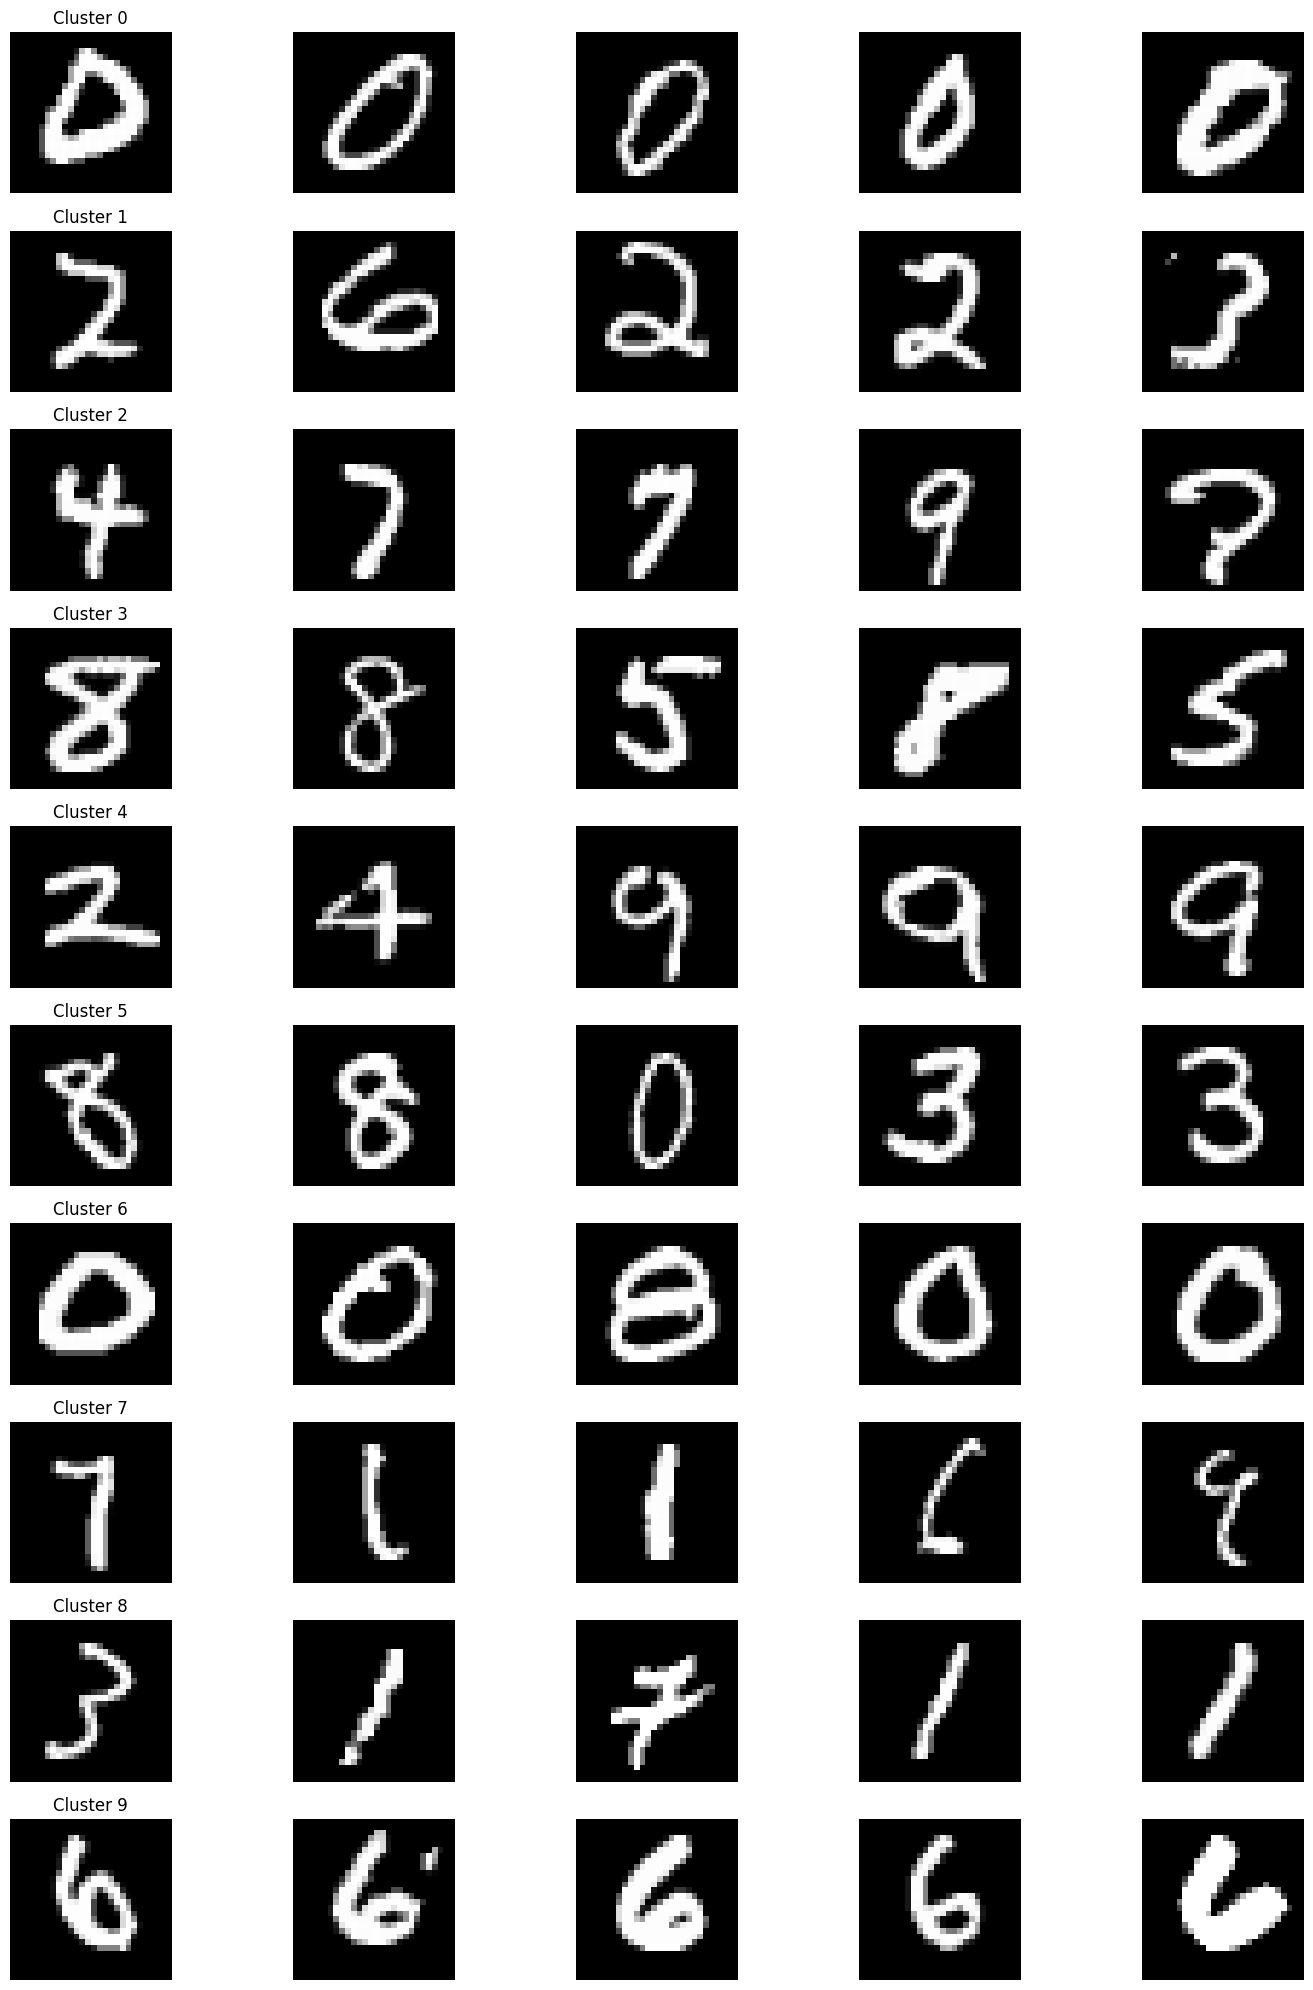

In [20]:
# Display Sample Images from Each K-Means Cluster

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 20))

for cluster_id in range(10):
    # Find images belonging to the current cluster
    cluster_indices = np.where(clusters == cluster_id)[0]

    # Select up to 5 images from the cluster
    selected_indices = cluster_indices[:5]

    for j, index in enumerate(selected_indices):
        position = cluster_id * 5 + j + 1

        plt.subplot(10, 5, position)
        plt.imshow(X_sample[index].reshape(28, 28), cmap="gray")
        plt.axis("off")

        if j == 0:
            plt.title(f"Cluster {cluster_id}")

plt.tight_layout()
plt.show()

Some centroids are relatively easy to interpret. Cluster 0 clearly resembles digit 0, while Cluster 9 appears similar to digit 6.

The other centroids look more like mixtures of different digits. For example, Cluster 1 appears to combine characteristics of digits 2, 6, and 3. Cluster 2 shows characteristics of digits 4, 7, and 9. This suggests that some clusters contain images of digits with similar shapes or writing patterns.

Questions and Answers

1. Do images within the same cluster look similar?

Only a few clusters contain mostly similar images. For example, Clusters 0 and 9 contain images with relatively similar shapes. Most clusters contain images with different digit shapes.


2. Does a cluster appear to contain mostly one digit?

Yes, Cluster 0 with digit 0 and Cluster 9 with digit 6.

3. Are some digits spread across multiple clusters?

Some digits are spread across multiple clusters. For example, digit 8 appears across Clusters 3, 5, and 6, while digit 1 appears across Clusters 7 and 8.

4. Which digits appear difficult for K-Means to separate?

Digits with similar shapes appear more difficult to separate. For example, digits 2, 3, and 6 appear together in Cluster 1, while digits 4, 7, and 9 appear together in Cluster 2.

Part 4 - Compare Clusters with the Actual Digit Labels

Create the comparison table

In [21]:
# Compare K-Means Clusters with Actual Digit Labels

import pandas as pd

# Create a cross-tabulation of clusters and actual digits
cluster_digit_table = pd.crosstab(
    clusters,
    y_sample
)

print(cluster_digit_table)

col_0    0    1    2    3    4    5    6    7    8    9
row_0                                                  
0      427    0   11   17    0   39   14    1    7    3
1        5    1  666   42    8    4   10    9   12    0
2        4    1    8    7  290   57    1  654   23  442
3       22    2   20  146    4  266    9    1  560    9
4        3    4   26   33  500   63   14  295   34  503
5       31    5   71  700    0  310    4    0  197   13
6      458    0    5    2    2    5   26    2    6    7
7        0  642   45   55   16   18   34   34   32   30
8        2  497   70   24   49  155   48   57   87   28
9       31    0   45    8   37   20  801    2   11    1


The cross-tabulation shows the number of images of each digit in each cluster. Some clusters are concentrated on one digit, while others contain two or three different digits. For example, Cluster 9 contains 801 images of digit 6, and Cluster 5 contains 700 images of digit 3.

On the other hand, Cluster 4 contains 503 images of digit 9 and 500 images of digit 4. This shows that Cluster 4 contains a mixture of two digits.

In [22]:
# Find the Most Common Actual Digit in Each Cluster

most_common_digit = cluster_digit_table.idxmax(axis=1)

print("Most common digit in each cluster:")
print(most_common_digit)

Most common digit in each cluster:
row_0
0    0
1    2
2    7
3    8
4    9
5    3
6    0
7    1
8    1
9    6
dtype: object


Questions and answers

1. Does each cluster mainly contain one digit?

No. Some clusters mainly contain one digit, such as Cluster 9 with digit 6 and Cluster 5 with digit 3. However, other clusters contain a mixture of two or more digits.

2. Which digits are grouped together?

Some digits are grouped together in the same clusters. For example, Cluster 4 contains many images of digits 9 and 4.

3. Which digits appear in multiple clusters?

Some digits appear in multiple clusters. For example, digit 0 appears  in Clusters 0 and 6.

4. Why might some digits be difficult to separate?

Digits with similar shapes and writing patterns are difficult to separate. People may also write the same digit in different ways.


Part 5 - Visualize the Clusters with PCA

Reduce the data from 784 dimensions to 2

In [23]:
# Reduce MNIST Data to Two Dimensions Using PCA

from sklearn.decomposition import PCA

# Create PCA with two principal components
pca = PCA(n_components=2)

# Transform the sample data
X_pca = pca.fit_transform(X_sample)

print("Original data shape:", X_sample.shape)
print("Reduced data shape:", X_pca.shape)

Original data shape: (10000, 784)
Reduced data shape: (10000, 2)


Visualize the K-Means clusters using PCA

The PCA plot reduces the 784 pixel features of each MNIST image to two principal components. The points are distributed across the two-dimensional space.

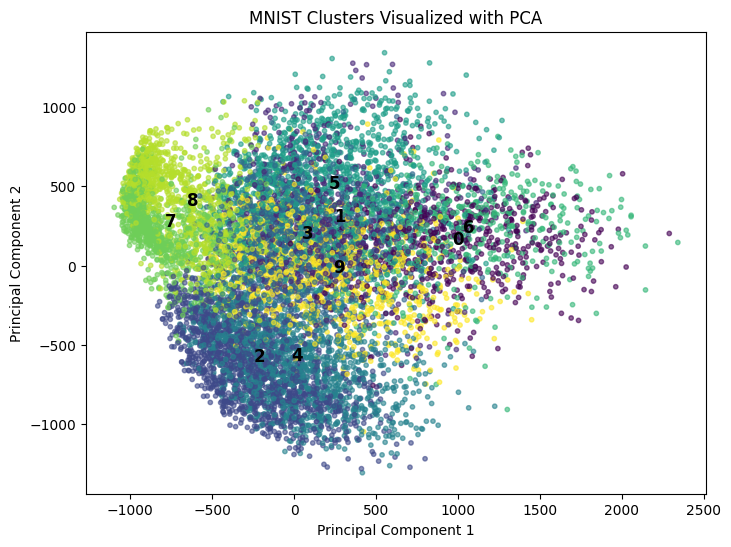

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Plot all observations
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=10,
    alpha=0.6
)

# Add the cluster number near the center of each cluster
for cluster_id in range(10):
    cluster_points = X_pca[clusters == cluster_id]

    # Calculate the center of the cluster in PCA space
    center_x = cluster_points[:, 0].mean()
    center_y = cluster_points[:, 1].mean()

    plt.text(
        center_x,
        center_y,
        str(cluster_id),
        fontsize=12,
        fontweight='bold'
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Clusters Visualized with PCA")
plt.show()



The visualization shows that some clusters are close to each other, such as Clusters 2 and 4, Clusters 7 and 9, and Clusters 0 and 6. This indicates that the images in these clusters have some similar characteristics in their pixel patterns. This is consistent with the previous cluster analysis, where some digits were grouped together, such as 7 and 9, 4 and 9, and 0 appearing in both Clusters 0 and 6.

In contrast, Clusters 6 and 7 are more distant from each other in the PCA space, suggesting that their images have more different visual characteristics.

1. Do the clusters appear separated?

The PCA plot shows that some groups are located in different areas of the two-dimensional space. For example, the green cluster is mainly located in the upper-left area, while the violet cluster is mainly located toward the lower-right side of the plot.



2. Are some clusters overlapping?

Yes. Some clusters are close to each other and show some overlap. For example, Clusters 2 and 4, Clusters 7 and 9, and Clusters 0 and 6 appear relatively close. This suggests that the images in these clusters have some similar visual characteristics.

3. Which groups appear to be more clearly separated?

Clusters 6 and 7 appear to be more clearly separated because they are located farther apart in the PCA space. This suggests that their images have more different visual characteristics.

4. Does the PCA visualization support what you observed from the cluster images?

Yes. The PCA visualization generally supports the observations from the cluster images.
The visualization shows that some clusters such as Clusters 2 and 4, Clusters 7 and 9, and Clusters 0 and 6 are close to each other.

This is consistent with the previous cluster analysis, where some digits were grouped together, such as 7 and 9, 4 and 9, and 0 appearing in both Clusters 0 and 6.


# Part 6 - Predict the Cluster of New Images

Select 10 new images

In [27]:
# Select 10 New Images Not Used to Train K-Means

# Find images that were not included in the training sample
all_indices = np.arange(len(X))
new_indices = np.setdiff1d(all_indices, sample_indices)[:10]

# Select the new images and their actual labels
X_new = X[new_indices]
y_new = y[new_indices]

print("New images shape:", X_new.shape)
print("Actual labels:", y_new)

New images shape: (10, 784)
Actual labels: ['5' '0' '4' '1' '2' '1' '3' '1' '4' '3']


Display the 10 new images

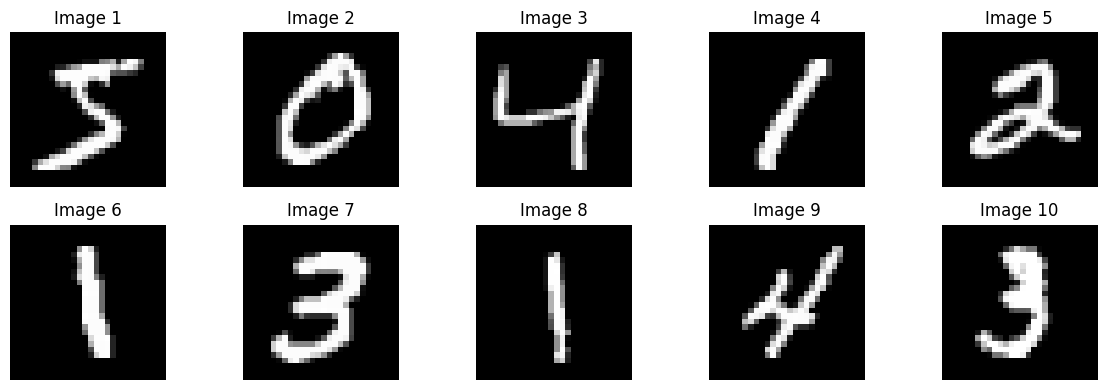

In [31]:
# Display the 10 New Images

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_new[i].reshape(28, 28), cmap="gray")
    plt.title(f"Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Prediction

In [28]:
# Predict the Clusters for the New Images

new_clusters = kmeans.predict(X_new)

print("Predicted clusters:", new_clusters)

Predicted clusters: [3 0 4 8 1 7 3 7 2 5]


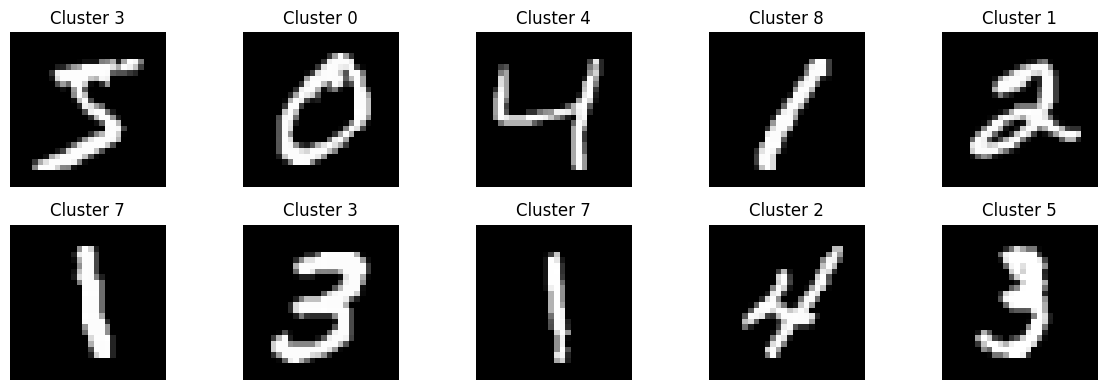

In [29]:
# Display New Images with Their Predicted Cluster Numbers

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_new[i].reshape(28, 28), cmap="gray")
    plt.title(f"Cluster {new_clusters[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

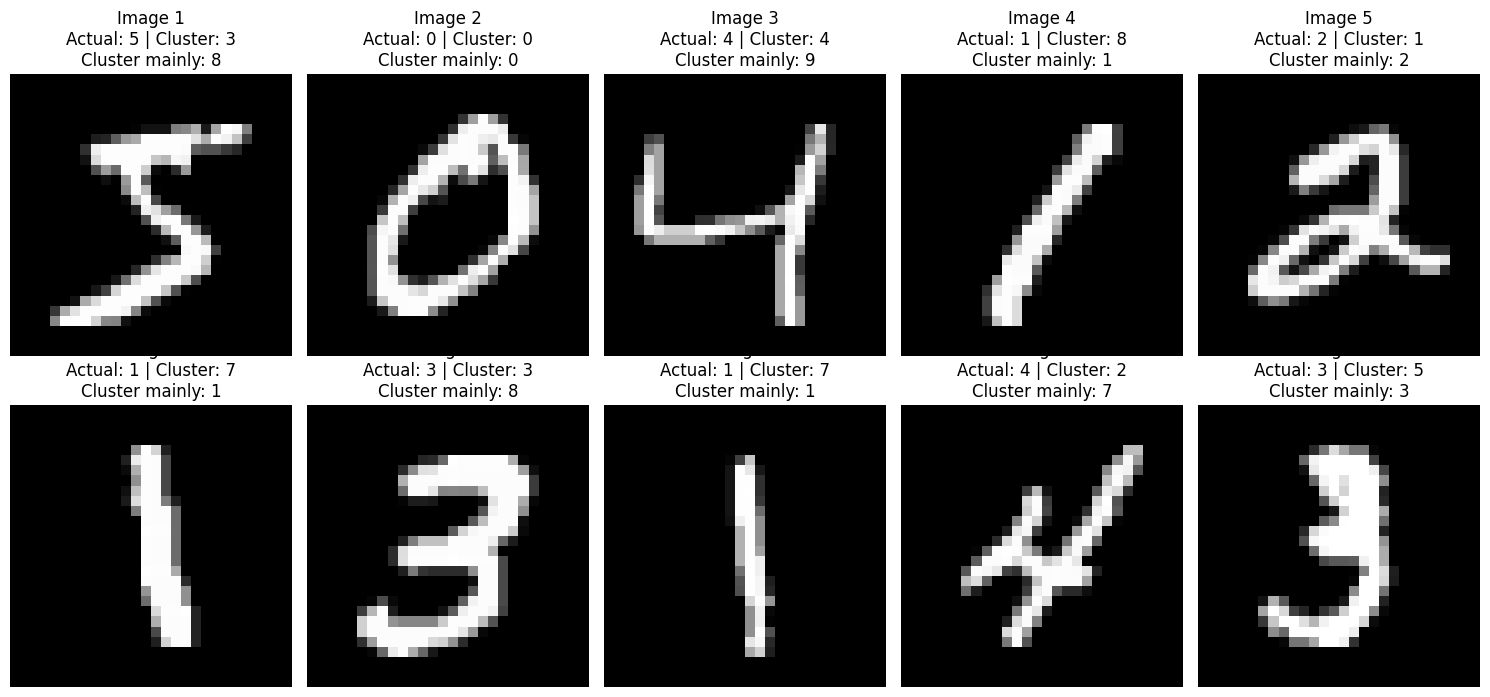

In [32]:
# Display New Images with Actual Digit, Predicted Cluster, and Previous Cluster Analysis

import matplotlib.pyplot as plt

# Predict the cluster of the new images
new_clusters = kmeans.predict(X_new)

# Dominant digit previously identified for each cluster
dominant_digits = {
    0: 0,
    1: 2,
    2: 7,
    3: 8,
    4: 9,
    5: 3,
    6: 0,
    7: 1,
    8: 1,
    9: 6
}

plt.figure(figsize=(15, 7))

for i in range(10):
    cluster = new_clusters[i]
    actual_digit = y_new[i]
    dominant_digit = dominant_digits[cluster]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_new[i].reshape(28, 28), cmap="gray")

    plt.title(
        f"Image {i+1}\n"
        f"Actual: {actual_digit} | Cluster: {cluster}\n"
        f"Cluster mainly: {dominant_digit}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

K-Means was used to predict the clusters of 10 new images that were not used during training. The predictions were consistent with the previous cluster analysis for images 2, 4, 5, 6, 8, and 10.

For images 1, 3, 7, and 9, the predicted cluster was mainly associated with a different digit than the actual digit. Image 1 was assigned to a cluster mainly associated with digit 8, Image 3 to a cluster mainly associated with digit 9, Image 7 to a cluster mainly associated with digit 8, and Image 9 to a cluster mainly associated with digit 7.

Questions and Answers

1. Which cluster was assigned to each image?

Each of the 10 new images was assigned to one of the 10 clusters previously learned by K-Means. The predicted cluster numbers are displayed with each image in the visualization. The assignments can then be compared with the actual digit labels and the previous cluster analysis.

2. Do images that look similar receive similar cluster assignments?

In general, images with similar visual characteristics tend to receive similar cluster assignments. This is because K-Means groups images according to their pixel patterns and visual characteristics rather than their actual digit labels.

3. Are any assignments surprising?

Yes. Some assignments are surprising because the original handwritten images do not clearly look like the digit mainly associated with their predicted clusters.

For example, Image 3 visually looks like a 4, but it was assigned to Cluster 4, which is mainly associated with digit 9.

4. Why might K-Means sometimes assign an image to an unexpected cluster?

K-Means assigns images based on the distance from the cluster centroids, not based on the actual digit labels. Some digits can have similar shapes, and the same digit can also be written in different ways. In addition, our previous cross-tabulation showed that several clusters contain multiple digits. Therefore, an image can be assigned to a cluster that contains a different dominant digit.


Image 1 → Cluster 3 (predicted digit 8) — Incorrect
Image 2 → Cluster 0 (predicted digit 0) — Correct
Image 3 → Cluster 4 (predicted digit 9) — Incorrect
Image 4 → Cluster 8 (predicted digit 1) — Correct
Image 5 → Cluster 1 (predicted digit 2) — Correct
Image 6 → Cluster 7 (predicted digit 1) — Correct
Image 7 → Cluster 3 (predicted digit 8) — Incorrect
Image 8 → Cluster 7 (predicted digit 1) — Correct
Image 9 → Cluster 2 (predicted digit 7) — Incorrect
Image 10 → Cluster 5 (predicted digit 3) — Correct

# Part 7: Final Analysis


Questions and Answers

1. What did K-Means discover in the MNIST dataset?

K-Means discovered groups of handwritten images based on their visual characteristics and pixel patterns. Some clusters were mainly associated with one digit, while other clusters contained a mixture of different digits.

2. What value of K did you choose, and why?

I chose K = 10 according to the elbow method. The graph showed that around K = 10, the reduction in inertia became smaller. Therefore, K = 10 was chosen as a reasonable number of clusters.

3. What did the cluster centroids tell you?

The centroids showed the average image characteristics of each cluster. Some centroids were easy to recognize, such as Cluster 0, which looked like digit 0, and Cluster 9, which looked similar to digit 6. Other centroids looked like a mixture of different digits.

4. Did the clusters correspond closely to particular digits?

Not always. Some clusters were mainly associated with one digit. For example, Cluster 9 contained many images of digit 6, while Cluster 5 contained many images of digit 3. However, several clusters contained a mixture of digits, such as Cluster 4, which contained many images of digits 9 and 4.

5. Which digits were difficult to separate?

Some digits were difficult to separate because they have similar shapes or different handwriting styles. For example, digits 4 and 9, 7 and 9, and 8 and 5 were grouped together in some clusters. The same digit could also appear in more than one cluster because people write the same digit differently.

6. What did the PCA visualization show?

The PCA visualization show the distribution of the clusters. some clusters appeared in different areas of the graph (6 and 7), while other clusters had some overlap (2 and 4).

7. What are some limitations of using K-Means for handwritten digit images?

K-Means has some limitations for handwritten images. Similar-looking digits can be placed in the same cluster.

8. How is this project different from Project 3, where you used supervised learning?

The two projects use different methods. In this project, we used an unsupervised learning method, while Project 3 used a supervised learning method.

Therefore, in this project, the actual digit labels were not used to train the model. K-Means discovered groups based on the characteristics of the images.

In Project 3, the target labels were provided during training, and the models Logistic Regression, SVM, and Random Forest learned from the labeled data to make predictions.

In [ ]:
'''
THANK YOU

'''